In [1]:
import phoenix
from phoenix import Hamiltonian
import pickle

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns



def plot_pauli_strings(paulis, *, reverse_chars=False, figsize=(10, 8), title="Pauli Strings", little_endian=True):
    """
    可视化一组等长 Pauli strings。

    横轴: qubit index
    纵轴: Pauli string index
    """
    if not paulis:
        raise ValueError("paulis 不能为空")

    n_rows = len(paulis)
    n_cols = len(paulis[0])

    if any(len(p) != n_cols for p in paulis):
        raise ValueError("所有 Pauli string 长度必须相同")

    if reverse_chars:
        paulis = [p[::-1] for p in paulis]

    color_map = {
        "X": np.array([0.89, 0.58, 0.58]),  # soft red
        "Y": np.array([0.55, 0.75, 0.55]),  # soft green
        "Z": np.array([0.55, 0.67, 0.87]),  # soft blue
        "I": np.array([0.78, 0.78, 0.78]),  # soft gray
    }

    img = np.zeros((n_rows, n_cols, 3), dtype=float)

    for i, p in enumerate(paulis):
        for j, ch in enumerate(p):
            if ch not in color_map:
                raise ValueError(f"不支持的 Pauli 字符: {ch}")
            img[i, j] = color_map[ch]

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img, aspect="auto", interpolation="nearest", origin="upper")

    ax.set_xlabel("Qubit index")
    ax.set_ylabel("Pauli string index")
    ax.set_title(title)

    ax.set_xticks(np.arange(n_cols))
    if little_endian:
        ax.set_xticklabels([f"q{n_cols - 1 - i}" for i in range(n_cols)])
    else:
        ax.set_xticklabels([f"q{i}" for i in range(n_cols)])

    step = max(1, n_rows // 12)
    ax.set_yticks(np.arange(0, n_rows, step))
    ax.set_yticklabels(np.arange(0, n_rows, step))

    ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    # legend_handles = [
    #     Patch(facecolor=color_map["X"], label="X"),
    #     Patch(facecolor=color_map["Y"], label="Y"),
    #     Patch(facecolor=color_map["Z"], label="Z"),
    #     Patch(facecolor=color_map["I"], label="I"),
    # ]
    # ax.legend(handles=legend_handles, bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    # plt.savefig("pauli_strings.png", dpi=300)
    plt.show()


In [2]:
with open('ham_1.pkl', 'rb') as f:
    ham = pickle.load(f)

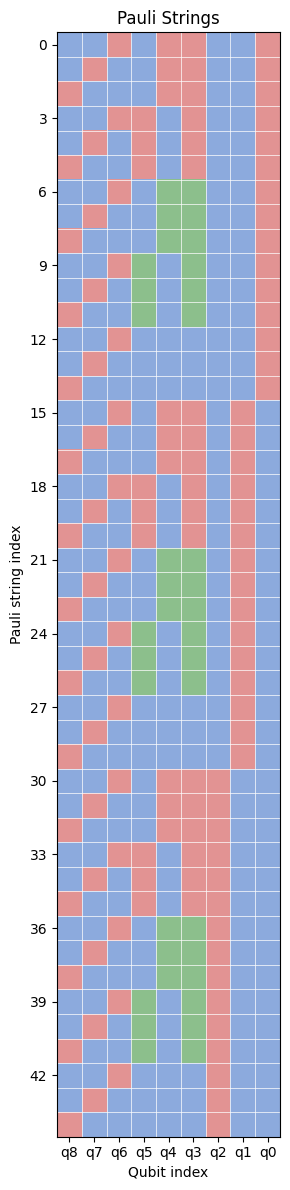

In [3]:
plot_pauli_strings(ham.paulis.to_labels(), figsize=(3, 12))

In [5]:
print(phoenix.primitive.simplification.heuristic_bsf_cost(ham.paulis.x, ham.paulis.z))
phoenix.primitive.simplification.search_best_clifford(ham)

33943.5


(SparsePauliOp(['ZZXZXIZZX', 'ZXZZXIZZX', 'XZZZXIZZX', 'ZZXXZXZZX', 'ZXZXZXZZX', 'XZZXZXZZX', 'ZZXZXZZZX', 'ZXZZXZZZX', 'XZZZXZZZX', 'ZZXYIYZZX', 'ZXZYIYZZX', 'XZZYIYZZX', 'ZZXZIZZZX', 'ZXZZIZZZX', 'XZZZIZZZX', 'ZZXZXIZXZ', 'ZXZZXIZXZ', 'XZZZXIZXZ', 'ZZXXZXZXZ', 'ZXZXZXZXZ', 'XZZXZXZXZ', 'ZZXZXZZXZ', 'ZXZZXZZXZ', 'XZZZXZZXZ', 'ZZXYIYZXZ', 'ZXZYIYZXZ', 'XZZYIYZXZ', 'ZZXZIZZXZ', 'ZXZZIZZXZ', 'XZZZIZZXZ', 'ZZXZXIXZZ', 'ZXZZXIXZZ', 'XZZZXIXZZ', 'ZZXXZXXZZ', 'ZXZXZXXZZ', 'XZZXZXXZZ', 'ZZXZXZXZZ', 'ZXZZXZXZZ', 'XZZZXZXZZ', 'ZZXYIYXZZ', 'ZXZYIYXZZ', 'XZZYIYXZZ', 'ZZXZIZXZZ', 'ZXZZIZXZZ', 'XZZZIZXZZ'],
               coeffs=[ 2.1885671 +0.j, -1.98449999+0.j,  3.83375958+0.j,  2.14583941+0.j,
  -1.94575633+0.j,  3.75891257+0.j,  0.55125854+0.j, -0.4998579 +0.j,
   0.96565132+0.j, -0.27255734+0.j,  0.24714346+0.j, -0.4774445 +0.j,
   1.08153991+0.j, -0.9806946 +0.j,  1.89455648+0.j, -1.98449999+0.j,
   1.79946057+0.j, -3.47629088+0.j, -1.94575633+0.j,  1.76432946+0.j,
  -3.40842278+0.j, -0.49985

In [6]:
phoenix.primitive.simplification.simplify_hamiltonian(ham)

(SparsePauliOp(['IIIZIIIIZ'],
               coeffs=[1.89455648+0.j]),
 [SimplificationStep(clifford=Instruction(name='cxz', num_qubits=2, num_clbits=0, params=[]), local_hamiltonian=SparsePauliOp(['IIIIIIIII'],
                coeffs=[0.+0.j]), qubits=(3, 4)),
  SimplificationStep(clifford=Instruction(name='cxz', num_qubits=2, num_clbits=0, params=[]), local_hamiltonian=SparsePauliOp(['IIIIIIIII'],
                coeffs=[0.+0.j]), qubits=(3, 5)),
  SimplificationStep(clifford=Instruction(name='cxx', num_qubits=2, num_clbits=0, params=[]), local_hamiltonian=SparsePauliOp(['IIIIIIIII'],
                coeffs=[0.+0.j]), qubits=(4, 5)),
  SimplificationStep(clifford=Instruction(name='cyz', num_qubits=2, num_clbits=0, params=[]), local_hamiltonian=SparsePauliOp(['IIIIIIIII'],
                coeffs=[0.+0.j]), qubits=(0, 1)),
  SimplificationStep(clifford=Instruction(name='cxx', num_qubits=2, num_clbits=0, params=[]), local_hamiltonian=SparsePauliOp(['IIIIIIIII'],
                coeffs=[

In [7]:
from phoenix.primitive.simplification import SimplificationStep, search_best_clifford

current_ham = ham
simp_steps: list[SimplificationStep] = []
avoid: tuple[int, int] = (-1, -1)

while current_ham.total_weight > 2:
    local_ham, nonlocal_ham = current_ham.separate_local_nonlocal()

    best_ham, best_cliff, qubits = search_best_clifford(nonlocal_ham, avoid)

    simp_steps.append(SimplificationStep(
        clifford=best_cliff,
        local_hamiltonian=local_ham,
        qubits=qubits))

    current_ham = best_ham
    avoid = qubits


Best Clifford: Instruction(name='cxz', num_qubits=2, num_clbits=0, params=[]), qubits: (3, 4), cost: 33300.00
Best Clifford: Instruction(name='cxz', num_qubits=2, num_clbits=0, params=[]), qubits: (3, 5), cost: 32413.50
Best Clifford: Instruction(name='cxx', num_qubits=2, num_clbits=0, params=[]), qubits: (4, 5), cost: 31738.50
Best Clifford: Instruction(name='cyz', num_qubits=2, num_clbits=0, params=[]), qubits: (0, 1), cost: 31138.50
Best Clifford: Instruction(name='cxx', num_qubits=2, num_clbits=0, params=[]), qubits: (0, 2), cost: 29878.50
Best Clifford: Instruction(name='cyz', num_qubits=2, num_clbits=0, params=[]), qubits: (6, 7), cost: 29278.50
Best Clifford: Instruction(name='cxx', num_qubits=2, num_clbits=0, params=[]), qubits: (6, 8), cost: 28018.50
Best Clifford: Instruction(name='czz', num_qubits=2, num_clbits=0, params=[]), qubits: (1, 2), cost: 27523.50
Best Clifford: Instruction(name='czz', num_qubits=2, num_clbits=0, params=[]), qubits: (7, 8), cost: 27028.50
Best Cliff

KeyboardInterrupt: 

In [8]:
ham

SparsePauliOp(['ZZXZXXZZX', 'ZXZZXXZZX', 'XZZZXXZZX', 'ZZXXZXZZX', 'ZXZXZXZZX', 'XZZXZXZZX', 'ZZXZYYZZX', 'ZXZZYYZZX', 'XZZZYYZZX', 'ZZXYZYZZX', 'ZXZYZYZZX', 'XZZYZYZZX', 'ZZXZZZZZX', 'ZXZZZZZZX', 'XZZZZZZZX', 'ZZXZXXZXZ', 'ZXZZXXZXZ', 'XZZZXXZXZ', 'ZZXXZXZXZ', 'ZXZXZXZXZ', 'XZZXZXZXZ', 'ZZXZYYZXZ', 'ZXZZYYZXZ', 'XZZZYYZXZ', 'ZZXYZYZXZ', 'ZXZYZYZXZ', 'XZZYZYZXZ', 'ZZXZZZZXZ', 'ZXZZZZZXZ', 'XZZZZZZXZ', 'ZZXZXXXZZ', 'ZXZZXXXZZ', 'XZZZXXXZZ', 'ZZXXZXXZZ', 'ZXZXZXXZZ', 'XZZXZXXZZ', 'ZZXZYYXZZ', 'ZXZZYYXZZ', 'XZZZYYXZZ', 'ZZXYZYXZZ', 'ZXZYZYXZZ', 'XZZYZYXZZ', 'ZZXZZZXZZ', 'ZXZZZZXZZ', 'XZZZZZXZZ'],
              coeffs=[ 2.1885671 +0.j, -1.98449999+0.j,  3.83375958+0.j,  2.14583941+0.j,
 -1.94575633+0.j,  3.75891257+0.j, -0.55125854+0.j,  0.4998579 +0.j,
 -0.96565132+0.j, -0.27255734+0.j,  0.24714346+0.j, -0.4774445 +0.j,
  1.08153991+0.j, -0.9806946 +0.j,  1.89455648+0.j, -1.98449999+0.j,
  1.79946057+0.j, -3.47629088+0.j, -1.94575633+0.j,  1.76432946+0.j,
 -3.40842278+0.j,  0.4998579 +0.j

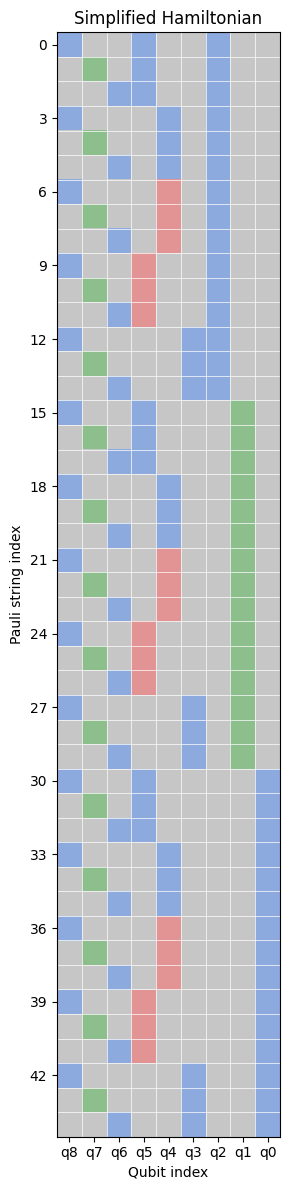

In [24]:
plot_pauli_strings(current_ham.paulis.to_labels(), figsize=(3, 12), title="Simplified Hamiltonian")

In [47]:
h = current_ham.apply_clifford(phoenix.CNOTEquivCliffordGate('y', 'y'), 1, 7)
phoenix.primitive.heuristic_bsf_cost(h.paulis.x, h.paulis.z)

26313.0

In [49]:
np.array_equal(h.paulis.x, current_ham.paulis.x), np.array_equal(h.paulis.z, current_ham.paulis.z)

(True, True)

In [45]:
h = current_ham.apply_clifford(phoenix.CNOTEquivCliffordGate('y', 'y'), 1, 8)
phoenix.primitive.heuristic_bsf_cost(h.paulis.x, h.paulis.z)

26583.0

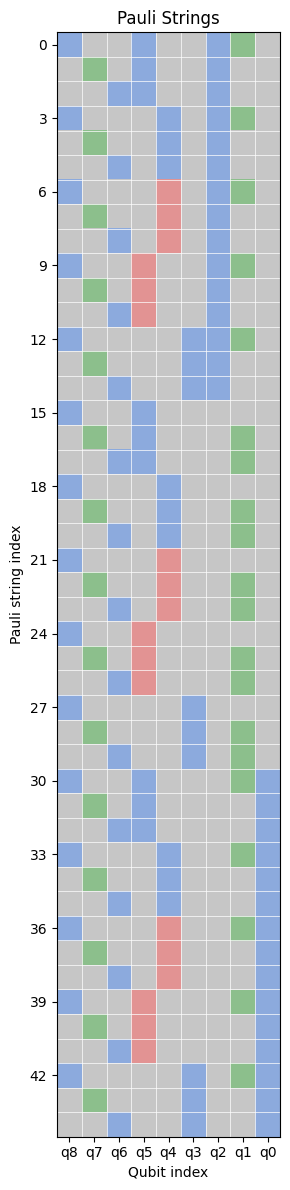

In [44]:
plot_pauli_strings(current_ham.apply_clifford(phoenix.CNOTEquivCliffordGate('y', 'y'), 1, 8).paulis.to_labels(), figsize=(3, 12))

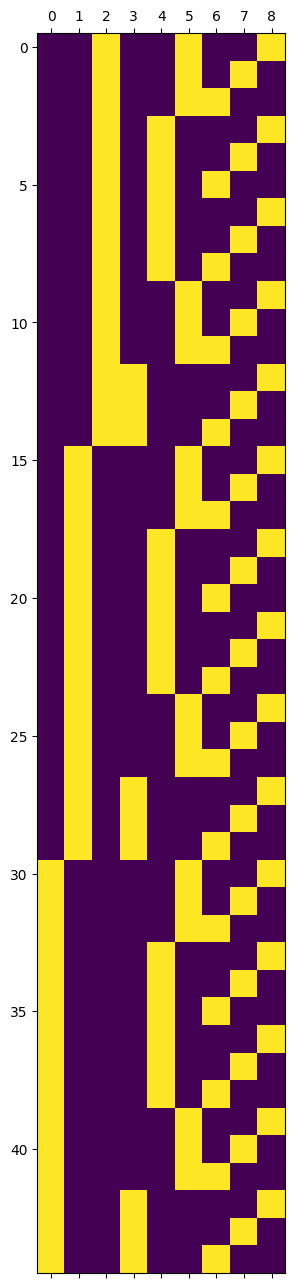

In [12]:
plt.matshow(current_ham.with_ops)